<a href="https://colab.research.google.com/github/doralalam/llm-engineering/blob/notes/003_week/day_2/028_pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Pipelines API**

The HuggingFace transformers library provides APIs at two different libraries

1. Pipeline - A High level API for using open-source models for typical inference tasks [tasks that are accomplished by running the pre-trained models]

2. Tokenizers and Models - A low level [granular level] API where we get to work with the underlying deep neural networks

#### **Here we are exploring the High level API: Pipelines**

We create a pipeline like this:

`my_pipeline = pipeline("the_task_i_want_to_do")`

Followed by

`result = my_pipeline("input_prompt")`





## Before we start: 2 important pro-tips for using Colab:

**Pro-tip 1:**

Data Science code often gives warnings and messages. They can mostly be safely ignored! Glance over them, and if something goes wrong later, perhaps they can give you a clue.

**Pro-tip 2:**

In the middle of running a Colab, you might get an error like this:

> Runtime error: CUDA is required but not available for bitsandbytes. Please consider installing [...]

This is a super-misleading error message! Please don't try changing versions of packages...

This actually happens because Google has switched out your Colab runtime, perhaps because Google Colab was too busy. The solution is:

1. Kernel menu >> Disconnect and delete runtime
2. Reload the colab from fresh and Edit menu >> Clear All Outputs
3. Connect to a new T4 using the button at the top right
4. Select "View resources" from the menu on the top right to confirm you have a GPU
5. Rerun the cells in the colab, from the top down, starting with the pip installs

And all should work great - otherwise, ask me!


### Difference between Training and Inference

1. **Training**

    - Training is the process of providing the model with the data to learn from it and adapt itself to get better for future task.

    - The model does this by updating it's internals - the parameters or the weights of the model

    - The process of training a model that was already pre-trained is known as **Fine Tuning**

2. **Inference**

    - The process of running or working with the model that was pre-trained is known as **Inference**

    - We use the model to produce new output for new input, taking the advantage of everything it learned from the training phase

    - Inference somestimes alson known as 'Execution' or 'Running a Model'


- The pipelines API in HuggingFace is used for Inference

In [1]:
!pip install -q --upgrade datasets==3.6.0 transformers==4.57.6

# the above shell command upgrades the packages datasets and transformers to specific versions mentioned if already installed, otherwise it will install them
# -q makes the output less verbose

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
# to check whether to connected to the T4 GPU

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed')>=0:
  print('Not connected to the GPU')
else:
  if gpu_info.find('Tesla T4') >=0:
    print('Successfully connected to T4 GPU')
  else:
    print('Not connected to T4 GPU')

Successfully connected to T4 GPU


In [3]:
# Imports

import torch
from google.colab import userdata
from huggingface_hub import login
from transformers import pipeline

In [4]:
# HF Token Validation

hf_token = userdata.get('HF_TOKEN')
if hf_token:
  print(f'HF_Token found and starts with {hf_token[0:3]}')
else:
  print('HF Token not found')

HF_Token found and starts with hf_


#### Using HuggingFace Pipelines

STEP-1: Create a pipeline - a function you can call then
```Python
my_pipeline = pipeline(task, model=xx, device=xx)
```
If we don't specify a model, then the HuggingFace selects the default model dedicated to the task
For NVIDIA GPU, we need to use "cuda" as the device.
For MAC, we need to use "mps" as the device

- cuda stands for **Compute Unified Device Architecture**, a parallel computing platform and programming model created by NVIDIA

- mps stands for **Metal Performance Shaders**, an Apple framework for that provides high performance, GPU accelerated graphics, image processing and machine learning primitives fine-tuned for Apple Silicon chips


STEP-2: Then call the pipeline as many times as you want
```Python
my_pipeline(input_1)
my_pipleine(input_2)
```

In [9]:
# sentiment_analyzer with default model assigned to that

my_sentiment_analyzer = pipeline('sentiment-analysis', device='cuda')
result = my_sentiment_analyzer('I am super excited to learn LLM Engineering')
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


[{'label': 'POSITIVE', 'score': 0.9995660185813904}]


In [10]:
result = my_sentiment_analyzer('The movie I watched recently was super boring')
print(result)

[{'label': 'NEGATIVE', 'score': 0.9997108578681946}]


#### Note

- For the first run after restarting the kernel,
 it takes higher run times this is due to downloading the model parameters

- For the next few runs, due to the caching, it gives the response much quicker compared to the first run

In [11]:
# sentiment analyzer with custom model from hugging face

best_sentiment_analyzer = pipeline('sentiment-analysis', model='nlptown/bert-base-multilingual-uncased-sentiment', device='cuda')
result = best_sentiment_analyzer('Feeling both happy and sad')
print(result)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda


[{'label': '5 stars', 'score': 0.39307358860969543}]


In [17]:
# named-entity-recognition

ner = pipeline('ner', device='cuda')
result = ner('AI Engineers can learn about different models from HuggingFace')
print(result)
print('--------------\n')
for entity in result:
  print(entity)

print('\n------------\n')
print('Entities found in the word as tokens: \n')
for entity in result:
  print(entity['word'])

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda


[{'entity': 'I-ORG', 'score': np.float32(0.99775994), 'index': 1, 'word': 'AI', 'start': 0, 'end': 2}, {'entity': 'I-ORG', 'score': np.float32(0.9467786), 'index': 2, 'word': 'Engineers', 'start': 3, 'end': 12}, {'entity': 'I-ORG', 'score': np.float32(0.9938964), 'index': 9, 'word': 'Hu', 'start': 51, 'end': 53}, {'entity': 'I-ORG', 'score': np.float32(0.9486667), 'index': 10, 'word': '##gging', 'start': 53, 'end': 58}, {'entity': 'I-ORG', 'score': np.float32(0.9889853), 'index': 11, 'word': '##F', 'start': 58, 'end': 59}, {'entity': 'I-ORG', 'score': np.float32(0.98294985), 'index': 12, 'word': '##ace', 'start': 59, 'end': 62}]
--------------

{'entity': 'I-ORG', 'score': np.float32(0.99775994), 'index': 1, 'word': 'AI', 'start': 0, 'end': 2}
{'entity': 'I-ORG', 'score': np.float32(0.9467786), 'index': 2, 'word': 'Engineers', 'start': 3, 'end': 12}
{'entity': 'I-ORG', 'score': np.float32(0.9938964), 'index': 9, 'word': 'Hu', 'start': 51, 'end': 53}
{'entity': 'I-ORG', 'score': np.floa

In [18]:
# Question Answering with Context

question="What are Hugging Face pipelines?"
context="Pipelines are a high level API for inference of LLMs with common tasks"

question_answerer = pipeline('question-answering', device='cuda')
reply = question_answerer(question=question, context=context)
print(reply)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


{'score': 0.24576981365680695, 'start': 35, 'end': 70, 'answer': 'inference of LLMs with common tasks'}


In [25]:
# text summarization

summarizer = pipeline('summarization', device='cuda')
text = """
The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing (NLP).
It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering, among others.
It's an extremely popular library that's widely used by the open-source data science community.
It lowers the barrier to entry into the field by providing Data Scientists with a productive, convenient way to work with transformer models.
"""
summary = summarizer(text, max_length=50, min_length=25, do_sample=False)
print(summary)
print('--------------------\n')
print(summary[0]['summary_text'])

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


[{'summary_text': ' The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing . It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering .'}]
--------------------

 The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing . It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering .


#### Note

`do_sample=False` - (Greedy Search)

- The model always picks the token with highest probability.
- This results in deterministic output i.e., if we run the code again with the same input, we will get the exact same output
_ This is useful in summarization tasks because it remains factual and concise

`do_sample=True` - (Sampling)

- The model always picks the next token based on a probability distribution
- It might pick the second or third most likely token
- This introduces randomness and creativity, which is great for story generation or creative writing, but can lead to less stable or 'hallucinated' summaries

In [28]:
# translation from english to french

translator = pipeline('translation_en_to_fr', device='cuda')
result = translator('The Data Scientists were truly amazed by the power and simplicity of the HuggingFace pipeline API.')
print(result)
print('-----------\n')
print('In French: \n')
print(result[0]['translation_text'])

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


[{'translation_text': "Les Data Scientists ont été vraiment étonnés par la puissance et la simplicité de l'API du pipeline HuggingFace."}]
-----------

In French: 

Les Data Scientists ont été vraiment étonnés par la puissance et la simplicité de l'API du pipeline HuggingFace.


In [30]:
# translation using custom model from huggingface

translator = pipeline('translation_en_to_es', model = 'Helsinki-NLP/opus-mt-en-es', device='cuda')
reply = translator('Hello')
print('In Spanish: \n')
print(reply[0]['translation_text'])

Device set to use cuda


In Spanish: 

Hola.


In [6]:
# classification

classifier = pipeline('zero-shot-classification', device = 'cuda')
reply = classifier("Hugging Face's Transformers library is amazing!", candidate_labels = ['technology', 'sports', 'politics'])
print(reply)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


{'sequence': "Hugging Face's Transformers library is amazing!", 'labels': ['technology', 'sports', 'politics'], 'scores': [0.9493839740753174, 0.03225007280707359, 0.018365919589996338]}


In [7]:
# text generation

generator = pipeline('text-generation', device='cuda')
result = generator("If there's one thing I want you to remember about using HuggingFace pipelines, it's")
print(result[0]['generated_text'])

# since the model is small, it might go off-track after certain tokens

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


If there's one thing I want you to remember about using HuggingFace pipelines, it's that when you use them in a workflow, you're actually writing something. And when you're using them to create a workflow you usually write something that you can use, so you've got a lot of flexibility when it comes to what you're using when you're creating a workflow.

For example, I know I just wrote a line of code, which is pretty simple, not to mention easy to use. I've never used anything that involved an actual HuggingFace pipeline, so I didn't want to mess with that.

I wanted to write something that I could use as a frontend for all kinds of things, so I created a couple of different frontend pipelines.

For the frontend, I created a couple of different "tasks" in a batch file:

1

2

3

4

5

6

7

8

9

10

11

12

13

14

15

16

17

18

19

20

21

22

23

24

25

26

27

28

29

30

31



Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/575 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


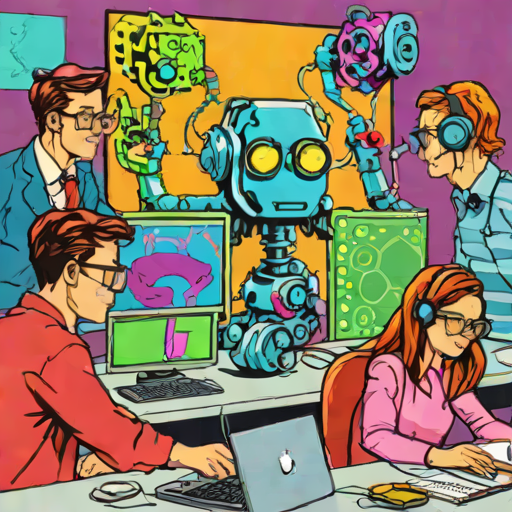

In [8]:
# Image generation

from diffusers import AutoPipelineForText2Image
from IPython.display import display
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype = torch.float16, variant="fp16")
pipe.to('cuda')
prompt = "A class of students learning AI engineering in a vibrant pop-art style"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)

#### Explaination for an image generation model

- `AutoPipelineForText2Image` - is a utility class from HuggingFace's diffusers library that handles text to image generation models

- `IPtython.display` - used to render the resulting PIL image `Python Image Library`

- `torch` - Python framework to handle deep learning tensors and GPU hardware acceleratoin

-------------------

- `"stabilityai/sdxl-turbo"` - downloads the model's weights

- `torch_dtype=torch.float16, variant="fp16"` - converts the models weights from 32-bit precision to 16-bit floating point precision. This cuts GPU vRAM usage to half and accelerates generation speed without noticeably dropping visual quality

- `pipe.to('cuda')` - moves the model from system CPU memory onto an NVIDIA GPU for hardware acceleration

----------------------

- `num_inference_steps = 4` - 4 denoising steps

- `guidance_scale=0.0` - setting this to 0 maximizes the generation speed and prevents visual artifacts

- `.image[0]` - extracts the first PIL image from the output array

#### How Diffusion Models Create Images

Diffusion models do not draw an image all at once. Instead they work in reverse from complete randomness:

- Step 0 (Start): The model starts with a canvas of pure random static (Gaussian noise).
- Step 1: The model looks at the text prompt and removes a chunk of noise, revealing very rough shapes.
- Step 2 to N: In each successive step, the model cleans up residual noise, adds finer details, sharper edges, and texture.
- Final Step: The clean, final image is extracted.

Think of it like a sculptor working with a block of marble:
- Step 1: Chiseling out the rough outline.
- Step 2: Sculpting the body features.
- Step 3: Adding intricate textures (hair, clothing folds).
- Step 4: Polishing the surface.



In [5]:
# Audio Generation (Synthesizer)

from transformers import pipeline
import torch
from datasets import load_dataset
import soundfile as sf
from IPython.display import Audio

synthesizer = pipeline("text-to-speech", "microsoft/speecht5_tts", device='cuda')
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speech = synthesizer("Hi to an artificial intelligence engineer, on the way to mastery!", forward_params={"speaker_embeddings":speaker_embedding})

Audio(speech["audio"], rate=speech["sampling_rate"])



config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/585M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/232 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/585M [00:00<?, ?B/s]

spm_char.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

cmu-arctic-xvectors.py: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/50.6M [00:00<?, ?B/s]

spkrec-xvect.zip:   0%|          | 0.00/17.9M [00:00<?, ?B/s]

Generating validation split: 0 examples [00:00, ? examples/s]

#### Breakdown

imports

- `transformers.pipeline` - library to load NLP and audio models

- `torch` - to convert the data from Python data structures [lists, tuples, dictionaries etc.,] to **PyTorch Tensor** a specialized array structure optimized for GPU execution

- `datasets`- to download HF datasets like pre-computed speaker embeddings

- `soundfile` - included for audio file handling (example: saving audio file to the disk, though not explicitly called here)

- `IPython.display.Audio` - Generates an interactive audio widget directly inside Jupyter or Google Colab notebooks

-----------------

- `pipeline` - initialising the pipeline for a model(text-to-speech here)

- `device='cuda'` - sends the model to NVIDIA GPU for fast, accelerated speech synthesis

- `load_dataset` - to load the dataset from HuggingFace, in this code **Pre-Computed voice profiles called x-vectors**

- `"matthijs/cmu-arctic-xvectors"` - this is the repository on the HuggingFace Dataset Hub

- `CMU ARCTIC` - A well known open source speech data base from Carnegie Mellon University

- `X-VECTORS` - instead of downloading raw audio files which are large and slow to process, user `matthijs` exctracted 512 dimensional numerical voice prints (x-vectors) from the recordings and hosted them for quick use

- `split = 'validation'` - datasets in huggingface are divided into splits `(train, test, validation)`. This condition ensures that specific partition get's downloaded instead of the entire dataset

- `trust_remote_code=True` - without this flag, HuggingFace might raise a security warning and prevents the dataset from loading. This is due to the custom python script hosted in the repository to parse and format the data properly

- `torch.tensor()` - convers the data from raw python data structures into PyTorch Tensor a PyTorch data structure for accelerated GPU performance

- `embeddings_dataset[7306]` - selects #7306 speaker profile from the dataset

- `unsqueeze(0)` - transforms the 1D tensor of shape (512,) to 2D tensor of shape (1,512) i.e., 1 row with 512 columns for parallel compute using GPU

- `forward_params = {"speaker_embeddings" : speaker_embedding}` - supplying the target voice profile to the model

----------------------

- `speech['audio']` - returns 1D array of generated raw audio waveforms

- `speech['sampling_rate']` - returns the audio sampling rate